# EverFlavor AI - Nutrition Quality: Macros per Serving and Nutrient-Rich Ingredients

**Team:** EverGlow
**Course:** ITAI 2277
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System

> **Run time** (measured on a laptop CPU, downloads already saved): under 1 minute.
> **First run:** about the same: it uses notebook 01's USDA files. Colab's free runtime takes about as long, or a little longer.

> **Status: built.** The code is in `src/everflavor/nutrition_quality.py` and is tested in
> `tests/test_nutrition_quality.py`. It uses only files earlier notebooks saved (the USDA SR Legacy download
> of notebook 01), so "Run all" downloads nothing.

---

## Purpose

Notebook 01 gives every recipe calories and macronutrients per serving. The Nutritionist Agent also needs
to say something about **quality**: is this dish high in protein, light on sodium, and does it bring fiber,
iron or vitamins?

**What can and can not be said honestly:**

- **Per serving, from the macros:** the share of calories from protein, fat and carbohydrate, protein per
  100 kcal and sodium per kcal. These are solid wherever the macros are (they are labeled `listed` or
  `estimated` in notebook 01).
- **Per ingredient, not per dish:** recipes list ingredients **without amounts**, so a dish's iron or
  vitamin total can not be computed. Instead each ingredient gets "rich in" tags from USDA (at least 20% of
  the Daily Value per 100 g, FDA's "high in" level applied per 100 g), and a dish is tagged "has an
  ingredient rich in iron". Spices and oils are left out (100 g of cinnamon is rich in iron, a recipe uses a
  teaspoon).
- **Not computed:** Nutri-Score, which needs values per 100 g of the dish (we have per serving, without the
  serving's weight) and the share of fruit and vegetables.

**USDA matches (fixed 2026-10-10):** notebook 01's automatic matches once picked a cured product for a generic
word ("beef" -> corned beef, "pork" -> salt pork). The 290 most-used ingredients are now matched by hand and the
automatic matches must cover every word of the name; section 3 shows the match status.

## Inputs and outputs

| | File | Made by |
|---|---|---|
| Input | `data/interim/recipes_all.parquet` (macros per serving, ingredient lists) | Notebook 01 (section 5.11) |
| Input | `data/processed/usda_ingredient_nutrition.csv` (each ingredient's USDA food) | Notebook 01 (section 5.8) |
| Input | USDA SR Legacy bulk download (`data/raw/usda_fdc/`) | Notebook 01 (section 5.8), downloaded there if missing |
| Output | `data/processed/ingredient_micronutrients.csv` (per 100 g fiber, minerals and vitamins, % Daily Value, "rich in" tags) | Notebook 07 (section 3), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/recipe_nutrition_quality.parquet` (per recipe: calorie shares, labels, nutrients its ingredients are rich in) | Notebook 07 (section 4), rebuilt on every run, not stored in GitHub |

## Contents

1. Setup
2. Daily Values and Labels
3. Nutrient-Rich Ingredients
4. Quality per Recipe
5. By Cuisine
6. Calorie Calculator (Week 7)
7. Team Decisions and Next Steps

---

## 1. Setup

The same setup as the other notebooks: it works unchanged in Google Colab, VS Code and Antigravity.

In [1]:
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
%pip install -q pandas pyarrow matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib.util
import os
import sys
from pathlib import Path

import pandas as pd

# -------------------------------------------------------
# 1. Where is this notebook running? Move to the project folder
#    (the one that holds notebooks/ and data/), as in notebook 01.
# -------------------------------------------------------
IN_COLAB = importlib.util.find_spec("google.colab") is not None   # only exists in Colab


def find_project_root(start):
    # Return the nearest folder at or above `start` with notebooks/ and data/, or None
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

# -------------------------------------------------------
# 2. The project's code (src/everflavor). If the notebook was opened on its
#    own, the missing files are downloaded from GitHub (temporary name
#    first, __init__.py last), exactly as in notebook 01.
# -------------------------------------------------------
SRC_DIR = PROJECT_ROOT / "src"
EVERFLAVOR_MODULES = ["__init__", "agent_tools", "calories", "charts", "checks", "cooking", "crew",
                      "cuisine", "diets", "environment", "evaluation", "features", "flags", "freshness", "ingredients",
                      "knowledge", "llm", "nutrition", "nutrition_quality", "parsing", "pipeline",
                      "progress", "recommend", "reporting", "review", "safety", "seasons", "sources",
                      "stores", "variants"]
EVERFLAVOR_URL = "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/src/everflavor/"
EVERFLAVOR_DIR = SRC_DIR / "everflavor"
missing_modules = [m for m in EVERFLAVOR_MODULES if not (EVERFLAVOR_DIR / f"{m}.py").exists()]
if missing_modules:
    import urllib.request
    EVERFLAVOR_DIR.mkdir(parents=True, exist_ok=True)
    for module in sorted(missing_modules, key=lambda m: m == "__init__"):
        partial = EVERFLAVOR_DIR / f"{module}.py.part"
        urllib.request.urlretrieve(f"{EVERFLAVOR_URL}{module}.py", partial)
        partial.replace(EVERFLAVOR_DIR / f"{module}.py")
    print(f"Downloaded {len(missing_modules)} project code file(s) (src/everflavor) from GitHub.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from everflavor.environment import short_path

REFRESH_DOWNLOADS = False   # True downloads the USDA file again (it is reused otherwise)
SPLIT_FILES = {s: Path(f"data/processed/recipes_{s}.parquet") for s in ["train", "val", "test"]}
ALL_RECIPES_FILE = Path("data/interim/recipes_all.parquet")
USDA_MATCHES_FILE = Path("data/processed/usda_ingredient_nutrition.csv")
USDA_DIR = Path("data/raw/usda_fdc")
MICRONUTRIENTS_FILE = Path("data/processed/ingredient_micronutrients.csv")
QUALITY_FILE = Path("data/processed/recipe_nutrition_quality.parquet")
Path("data/processed").mkdir(parents=True, exist_ok=True)

print(f"Runtime        : {'Google Colab' if IN_COLAB else 'Local Jupyter (VS Code / Antigravity / JupyterLab)'}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
missing_inputs = [str(p) for p in [*SPLIT_FILES.values(), ALL_RECIPES_FILE, USDA_MATCHES_FILE] if not p.exists()]
if missing_inputs:
    print("\nMISSING notebook 01 outputs:", ", ".join(missing_inputs))
    print("Run notebook 01 first (all of Week 5), then run this notebook again.")
else:
    print("Notebook 01 outputs found.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
Notebook 01 outputs found.


In [3]:
import matplotlib.pyplot as plt

from everflavor.charts import set_chart_style, show_figure
from everflavor.nutrition_quality import (
    DAILY_VALUES,
    MACRO_LABELS,
    RICH_SHARE,
    SMALL_AMOUNT_CATEGORIES,
    ingredient_micronutrients,
    macro_quality,
    recipe_rich_in,
)

set_chart_style()
recipes = pd.read_parquet(ALL_RECIPES_FILE, columns=["recipe_id", "recipe_name", "cuisine_family", "ingredient_list",
                                                     "calories_per_serving", "protein_g", "fat_g", "carbs_g",
                                                     "sodium_mg", "nutrition_source"])
print(f"{len(recipes):,} recipes; nutrition listed for {recipes['nutrition_source'].eq('listed').mean():.0%}, "
      "estimated for the rest (notebook 01)")

291,755 recipes; nutrition listed for 84%, estimated for the rest (notebook 01)


---

## 2. Daily Values and Labels

FDA Daily Values for adults (2020 Nutrition Facts label). An ingredient is "rich in" a nutrient at
`RICH_SHARE` (20%) of the Daily Value per 100 g. The macro labels are shares of calories (4 kcal per gram of
protein or carbohydrate, 9 of fat).

In [4]:
print(pd.DataFrame([{"nutrient": k, "USDA name": n, "Daily Value": f"{dv:g} {u}"} for k, (n, dv, u) in DAILY_VALUES.items()]).to_string(index=False))
print(f"\nRich in: at least {RICH_SHARE:.0%} of the Daily Value per 100 g; left out: {', '.join(sorted(SMALL_AMOUNT_CATEGORIES))}")
print("\nMacro labels:")
for label, rule in MACRO_LABELS.items():
    print(f"  {label:22s} {rule}")

   nutrient                      USDA name Daily Value
      fiber           Fiber, total dietary        28 g
       iron                       Iron, Fe       18 mg
    calcium                    Calcium, Ca     1300 mg
  potassium                   Potassium, K     4700 mg
  magnesium                  Magnesium, Mg      420 mg
  vitamin_c Vitamin C, total ascorbic acid       90 mg
  vitamin_a                 Vitamin A, RAE      900 µg
  vitamin_d            Vitamin D (D2 + D3)       20 µg
vitamin_b12                   Vitamin B-12      2.4 µg
     folate                    Folate, DFE      400 µg

Rich in: at least 20% of the Daily Value per 100 g; left out: Fats and Oils, Spices and Herbs

Macro labels:
  high_protein           at least 20% of calories from protein
  lower_fat              less than 30% of calories from fat
  lower_carb             less than 26% of calories from carbohydrate
  lower_sodium_density   at most 1 mg sodium per kcal


---

## 3. Nutrient-Rich Ingredients

Every ingredient notebook 01 matched to a USDA food gets its fiber, minerals and vitamins per 100 g. The
`match` column says whether the match was hand-checked; automatic matches of generic words can be wrong.

In [5]:
matches = pd.read_csv(USDA_MATCHES_FILE)
micronutrients = ingredient_micronutrients(matches, USDA_DIR)
micronutrients.to_csv(MICRONUTRIENTS_FILE, index=False)
print(f"{len(micronutrients):,} ingredients; rich in at least one nutrient: {micronutrients['rich_in'].map(len).gt(0).mean():.0%}")
print(f"Match status: {micronutrients['match'].value_counts().to_dict() if 'match' in micronutrients else 'not recorded'}")
examples = ["lentil", "spinach", "salmon", "almond", "orange", "milk", "beef", "pork"]
micronutrients[micronutrients["ingredient"].isin(examples)][["ingredient", "usda_description", "match", "rich_in"]]

34,471 ingredients; rich in at least one nutrient: 57%
Match status: {'automatic': 34181, 'hand-checked': 290}


,ingredient,usda_description,match,rich_in
11,milk,"Milk, whole, 3.25% milkfat, with added vitamin D",hand-checked,[]
95,almond,"Nuts, almonds",hand-checked,"[fiber, iron, calcium, magnesium]"
97,spinach,"Spinach, raw",hand-checked,"[vitamin_c, vitamin_a, folate]"
110,orange,"Oranges, raw, Florida",automatic,[vitamin_c]
367,salmon,"Fish, salmon, Atlantic, farmed, raw",hand-checked,"[vitamin_d, vitamin_b12]"
394,beef,"Beef, composite of trimmed retail cuts, separa...",hand-checked,[vitamin_b12]
430,lentil,"Lentils, raw",automatic,"[fiber, iron, folate]"
559,pork,"Pork, fresh, composite of trimmed retail cuts ...",hand-checked,[vitamin_b12]


---

## 4. Quality per Recipe

In [6]:
quality = macro_quality(recipes)
quality["rich_in"] = recipe_rich_in(recipes, micronutrients)
keep = ["recipe_id", "protein_pct_kcal", "fat_pct_kcal", "carb_pct_kcal", "protein_g_per_100kcal",
        "sodium_mg_per_kcal", *MACRO_LABELS, "rich_in"]
quality[keep].to_parquet(QUALITY_FILE, index=False)
print(f"Saved {len(quality):,} recipes to {QUALITY_FILE}")
print((quality[list(MACRO_LABELS)].mean() * 100).round(1).rename("% of recipes").to_string())

Saved 291,755 recipes to data\processed\recipe_nutrition_quality.parquet
high_protein            30.7
lower_fat               28.4
lower_carb              31.6
lower_sodium_density    49.7


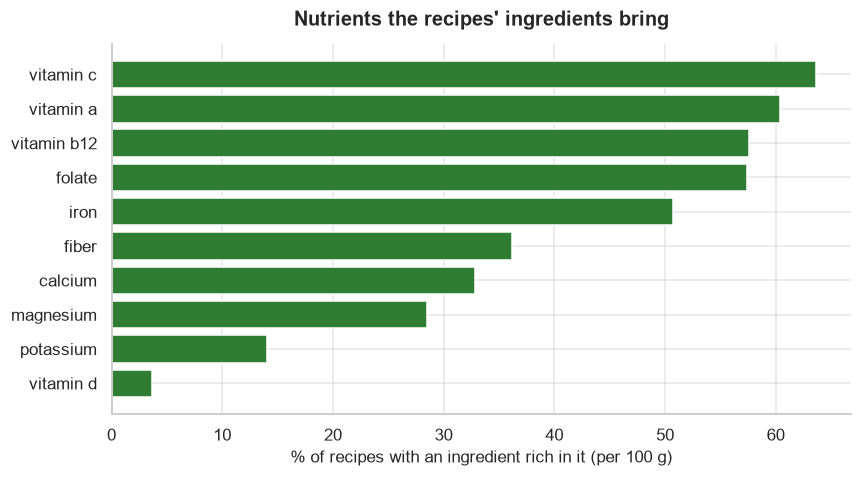

In [7]:
# Chart: how often a recipe has at least one ingredient rich in each nutrient
shares = pd.Series([n for items in quality["rich_in"] for n in items]).value_counts().div(len(quality)).mul(100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(shares.index[::-1].str.replace("_", " "), shares.values[::-1], color="#2E7D32")
ax.set_xlabel("% of recipes with an ingredient rich in it (per 100 g)")
ax.set_title("Nutrients the recipes' ingredients bring")
show_figure(fig, "nb07_01_rich_in")

---

## 5. By Cuisine

In [8]:
by_cuisine = quality[quality["cuisine_family"] != "Other"].groupby("cuisine_family")[
    ["protein_pct_kcal", "fat_pct_kcal", "carb_pct_kcal", *MACRO_LABELS]].mean()
by_cuisine[list(MACRO_LABELS)] = by_cuisine[list(MACRO_LABELS)].mul(100)
by_cuisine.round(1)

,protein_pct_kcal,fat_pct_kcal,carb_pct_kcal,high_protein,lower_fat,lower_carb,lower_sodium_density
cuisine_family,,,,,,,
African,16.4,41.1,42.5,30.4,33.9,31.8,59.6
Asian,20.0,41.1,39.0,39.3,31.3,34.9,42.5
European,16.6,46.2,37.2,29.5,22.8,36.8,50.4
Latin American,18.6,41.6,39.8,38.1,31.1,34.3,43.8
Middle Eastern,15.4,42.8,41.8,25.0,30.0,29.7,58.1


---

## 6. Calorie Calculator (Week 7)

The proposal's first success metric: calories within **5%** of a careful count from the same data. The
calculator (`src/everflavor/calories.py`) turns each ingredient line into grams ("1 cup chopped onion" =
160 g, from USDA's own household weights), multiplies by the USDA calories per 100 g and lists every line
it could not count, never counting it as zero.

The check uses the 1,000 Hugging Face sample recipes from notebook 01: they list each line's weight in
grams and the recipe's calories (from Edamam, also built on USDA data), so they are a reference, not a
perfect truth. Three ways are measured:

- **given grams + names:** the source's grams and clean ingredient names, as the Chef Agent will give them.
- **parsed grams + names:** the amounts read from the text ("1 1/2 cups").
- **parsed grams, line names:** names read from the text too, as for a recipe pasted by a user.

In [9]:
import json

import numpy as np

from everflavor.calories import calorie_accuracy, recipe_calories, usda_portions

HF_SAMPLE_FILE = Path("data/raw/hf_recipes_sample.csv")
CALORIE_CHECK = {}
if HF_SAMPLE_FILE.exists():
    hf = pd.read_csv(HF_SAMPLE_FILE)
    portions = usda_portions(USDA_DIR)
    fdc_of = dict(zip(matches["ingredient"], matches["fdc_id"].astype(int)))
    kcal_of = dict(zip(matches["fdc_id"].astype(int), matches["kcal_100g"]))
    hf_items = [json.loads(s) for s in hf["ingredients"]]
    for label, given, named in [("given grams + names", True, True), ("parsed grams + names", False, True),
                                ("parsed grams, line names", False, False)]:
        results = [recipe_calories([i["text"] for i in items], None, fdc_of, kcal_of, portions,
                                   grams=[i.get("weight") for i in items] if given else None,
                                   names=[i["food"] for i in items] if named else None) for items in hf_items]
        estimate = np.array([r["kcal_total"] for r in results])
        complete = np.array([r["counted_share"] >= 0.999 for r in results])
        CALORIE_CHECK[label] = {**calorie_accuracy(estimate[complete], hf["calories"].to_numpy(float)[complete]),
                                "recipes fully counted": f"{complete.mean():.0%}"}
    print(pd.DataFrame(CALORIE_CHECK).T.to_string())
    example = recipe_calories([i["text"] for i in hf_items[0]], hf["servings"].iloc[0], fdc_of, kcal_of, portions)
    print()
    print(f"Example: {hf['recipe_name'].iloc[0]} - {example['kcal_per_serving']} kcal per serving "
          f"(listed {hf['calories'].iloc[0] / hf['servings'].iloc[0]:.0f}); counted {example['counted_share']:.0%} of lines")
    print(example["lines"][["text", "grams", "method", "kcal"]].round(1).to_string(index=False))
else:
    print(f"{HF_SAMPLE_FILE} not found: run notebook 01 (section 2) first.")

                            n median_error within within_10pct recipes fully counted
given grams + names       687       0.0223   0.63        0.729                   69%
parsed grams + names      289       0.0715  0.436        0.567                   29%
parsed grams, line names  123       0.0715  0.455        0.569                   12%

Example: Classic Cabbage Slaw with Grandmother Shinn's Dressing - 92.4 kcal per serving (listed 85); counted 100% of lines
                                    text  grams           method  kcal
                1 tablespoon kosher salt   18.0       negligible   0.0
                            2 cups water  474.0       negligible   0.0
           4 cups shredded green cabbage  356.0     usda portion  89.0
       1 cup peeled and shredded carrots  142.0 category density  58.2
                3/4 cup minced scallions   75.0     usda portion  24.0
                            2 large eggs  112.0     usda portion 160.2
             1/2 cup apple cider vinega

---

## 7. Team Decisions and Next Steps

1. **Hand-check the most used automatic USDA matches** (notebook 01 now avoids cured and processed foods
   for generic words). Better matches are the largest gain left for the calorie calculator (section 6).
2. **Labels:** confirm the macro label rules (`MACRO_LABELS`) with the team's nutrition source.
3. **Amounts:** the calorie calculator (section 6) reads amounts from ingredient lines; the same grams could
   give per-serving vitamin totals for Hugging Face, TheMealDB and agent-written recipes.
4. **Agent output:** the Chef Agent should give each ingredient's weight in grams; with known grams the
   calculator is closest to the 5% target.
5. **Wording for the agent:** "has an ingredient rich in iron", never "gives you X mg of iron".

---

## Plan status

In [10]:
PLAN = pd.DataFrame([
    ("3 Nutrient-rich ingredients", f"built: {len(micronutrients):,} ingredients"),
    ("4 Quality per recipe", f"built: {len(quality):,} recipes"),
    ("5 By cuisine", "built"),
    ("6 Calorie calculator", f"built: {CALORIE_CHECK['given grams + names']['median_error']:.1%} median error with known grams"
                              if CALORIE_CHECK else "built; run notebook 01 for the Hugging Face sample"),
    ("Per-dish vitamin totals", "possible from the calculator's grams (next step)"),
], columns=["step", "status"])
print(PLAN.to_string(index=False))

                       step                                           status
3 Nutrient-rich ingredients                        built: 34,471 ingredients
       4 Quality per recipe                           built: 291,755 recipes
               5 By cuisine                                            built
       6 Calorie calculator        built: 2.2% median error with known grams
    Per-dish vitamin totals possible from the calculator's grams (next step)
